In [14]:
import os 
from tqdm import tqdm 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.io import wavfile 


In [ ]:
df = pd.read_csv('meta/esc50.csv')
df.set_index('filename', inplace = True)

for f in df.index: 
    rate, signal = wavfile.read('audio/' +f)
    df.at[f,'length'] = signal.shape[0]/rate #positional based indexing
    

In [12]:
#class distribution 
classes = list(np.unique(df.category))
class_dist = df.groupby(['category'])['length'].mean()

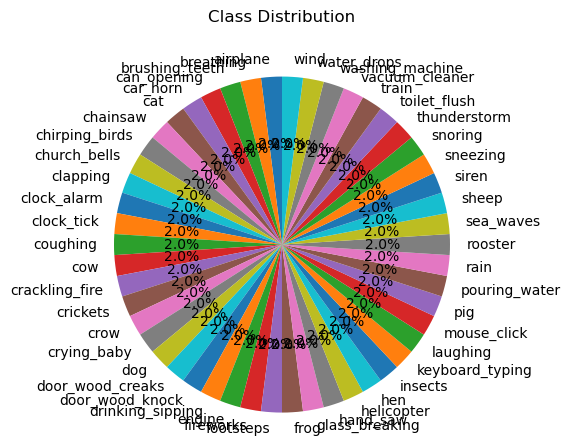

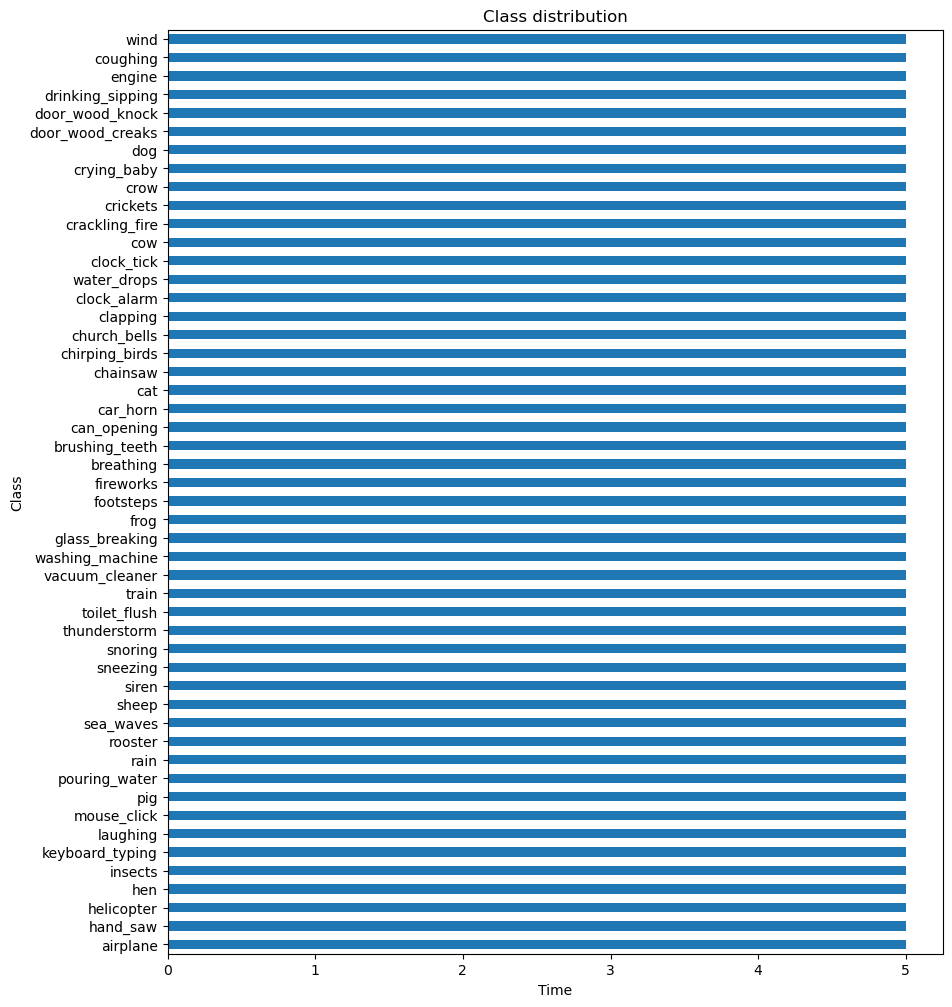

In [27]:
#plotting a piechart 
fig, ax = plt.subplots()
ax.set_title('Class Distribution', y=1.08)
ax.pie(class_dist, labels=class_dist.index, autopct ='%1.1f%%', 
        shadow=False, startangle=90)
ax.axis('equal')
plt.show()

df.reset_index(drop=True, inplace=True)

#plotting in barchart 
class_dist.sort_values().plot(kind='barh', figsize=(10,12))
plt.title('Class distribution')
plt.xlabel('Time')
plt.ylabel('Class')
plt.show()
 